# Logistic Regression for Loan Performance Prediction

## Objective

The objective of this notebook is to develop a Logistic Regression model capable of predicting whether a loan is:

- Performing (1)
- Non-Performing (0)

Since the dataset is highly imbalanced, the model uses **class weighting** to give greater importance to the minority class during training.

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC
- Classification Report
- Confusion Matrix
- Feature Coefficients

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# LOAD DATASET

df = pd.read_csv("clean_loanset1.csv")

In [3]:
# CREATE TARGET VARIABLE

df["Target"] = df["loan_status"].apply(
    lambda x: 1 if x in ["Current", "Fully Paid"] else 0
)

In [4]:
# CHECK TARGET DISTRIBUTION

print(df["Target"].value_counts())

print()

print(round(df["Target"].value_counts(normalize=True)*100,2))

Target
1    9822
0     178
Name: count, dtype: int64

Target
1    98.22
0     1.78
Name: proportion, dtype: float64


In [5]:
# CREATE TERM GROUP

df["term_group"] = df["term"].apply(
    lambda x: "Short Term" if "36" in str(x) else "Long Term"
)

In [6]:
# SELECT FEATURES


features = [

    "loan_amount",

    "interest_rate",

    "consolidated_annual_income",

    "consolidated_debt_to_income",

    "delinq_2y",

    "months_since_last_delinq",

    "inquiries_last_12m",

    "tax_liens",

    "num_historical_failed_to_pay",

    "loan_purpose",

    "application_type",

    "homeownership",

    "consolidated_verified_income",

    "term_group"

]

In [7]:
# ENCODE CATEGORICAL VARIABLES


X = pd.get_dummies(

    df[features],

    drop_first=True

)

y = df["Target"]

In [8]:
# SPLIT DATASET


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [9]:
# SCALE NUMERICAL FEATURES


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [10]:
# TRAIN BALANCED LOGISTIC REGRESSION


model = LogisticRegression(

    class_weight="balanced",

    max_iter=3000,

    random_state=42

)

model.fit(

    X_train_scaled,

    y_train

)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [11]:
# PREDICTIONS


y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:,1]

In [12]:
# EVALUATION METRICS


print("Accuracy :", round(accuracy_score(y_test,y_pred),3))

print("Precision:", round(precision_score(y_test,y_pred),3))

print("Recall   :", round(recall_score(y_test,y_pred),3))

print("F1 Score :", round(f1_score(y_test,y_pred),3))

print()

print("ROC AUC :", round(roc_auc_score(y_test,y_prob),3))

Accuracy : 0.697
Precision: 0.992
Recall   : 0.697
F1 Score : 0.818

ROC AUC : 0.762


In [13]:
# CLASSIFICATION REPORT


print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.04      0.69      0.08        36
           1       0.99      0.70      0.82      1964

    accuracy                           0.70      2000
   macro avg       0.52      0.70      0.45      2000
weighted avg       0.97      0.70      0.81      2000



In [14]:
# CONFUSION MATRIX


cm = confusion_matrix(y_test,y_pred)

print(cm)

[[  25   11]
 [ 596 1368]]


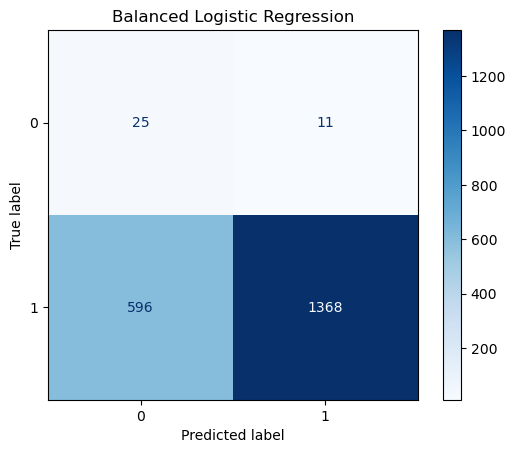

In [15]:
# PLOT CONFUSION MATRIX


disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Balanced Logistic Regression")

plt.show()

In [16]:
# FEATURE COEFFICIENTS


coefficients = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":model.coef_[0]

})

coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients.sort_values(

    by="Absolute",

    ascending=False,

    inplace=True

)

coefficients.head(20)

,Feature,Coefficient,Absolute
1,interest_rate,-0.665367,0.665367
9,loan_purpose_credit_card,0.462447,0.462447
10,loan_purpose_debt_consolidation,0.366557,0.366557
17,loan_purpose_renewable_energy,0.274396,0.274396
7,tax_liens,0.265326,0.265326
21,homeownership_OWN,-0.198551,0.198551
3,consolidated_debt_to_income,0.183660,0.183660
24,consolidated_verified_income_Verified,-0.168539,0.168539
22,homeownership_RENT,-0.151787,0.151787
2,consolidated_annual_income,-0.148581,0.148581


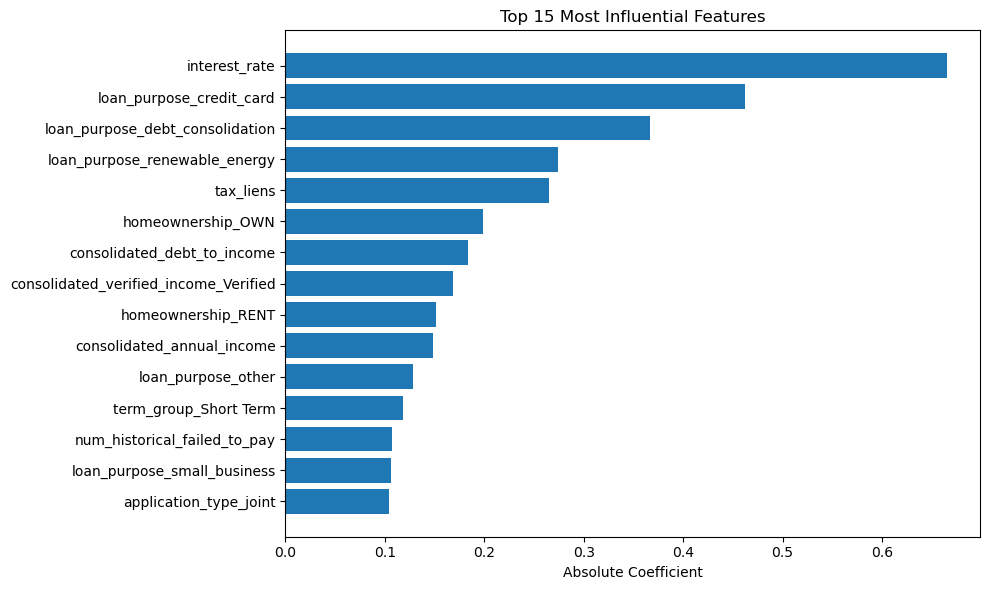

In [17]:
# PLOT TOP COEFFICIENTS


top15 = coefficients.head(15)

plt.figure(figsize=(10,6))

plt.barh(

    top15["Feature"],

    top15["Absolute"]

)

plt.gca().invert_yaxis()

plt.xlabel("Absolute Coefficient")

plt.title("Top 15 Most Influential Features")

plt.tight_layout()

plt.show()

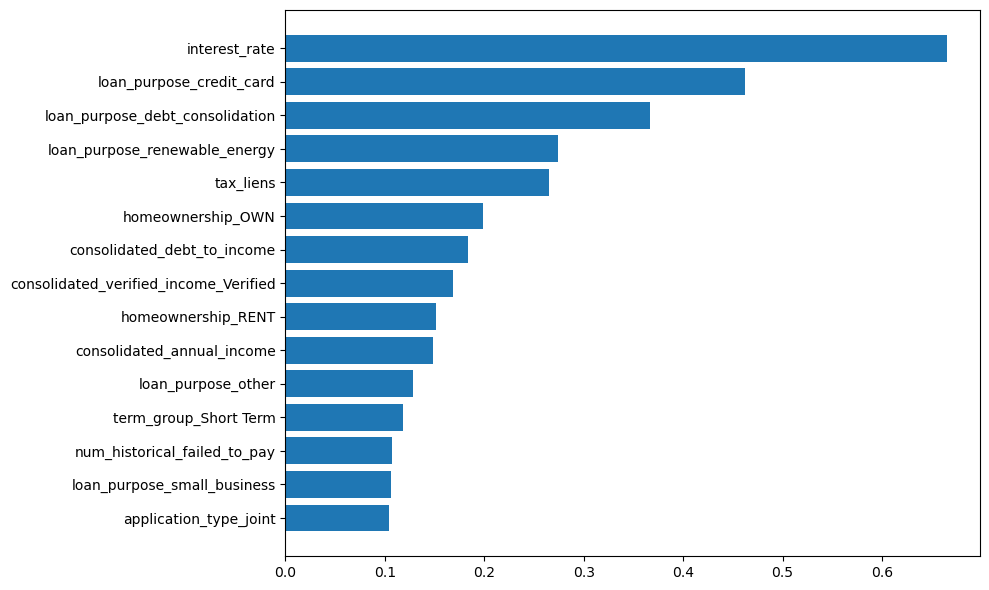

In [18]:
# SAVE FIGURE


plt.figure(figsize=(10,6))

plt.barh(

    top15["Feature"],

    top15["Absolute"]

)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(

    "logistic_feature_coefficients.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# Interpretation

The balanced Logistic Regression model was developed to address the severe class imbalance in the lending dataset by assigning greater importance to non-performing loans during model training.

The model achieved the following performance:

- Accuracy: **69.7%**
- Precision: **99.2%**
- Recall: **69.7%**
- F1 Score: **81.8%**
- ROC AUC: **0.762**

The ROC AUC score of **0.762** indicates that the model has a moderate ability to distinguish between performing and non-performing loans.

The confusion matrix shows that the model correctly identified **25 of the 36 non-performing loans**, representing approximately **69%** of the minority class. This is a significant improvement over the previous Logistic Regression model, which failed to identify any non-performing loans.

However, the model also misclassified **596 performing loans** as non-performing. This increase in false positives is an expected consequence of using balanced class weights to improve minority class detection.

Overall, the balanced Logistic Regression model provides a more practical solution for credit risk prediction than the standard Logistic Regression model, as it is capable of identifying high-risk loans rather than predicting nearly all loans as performing.

# Business Insight

From a lending perspective, identifying borrowers who are likely to default is generally more valuable than maximizing overall prediction accuracy.

The balanced Logistic Regression model demonstrates that improving the detection of high-risk borrowers requires accepting a higher number of false positive predictions. Although some low-risk borrowers may be flagged for additional review, this approach reduces the likelihood of overlooking genuinely risky loans.

The model can therefore serve as an effective screening tool to support loan officers during credit evaluation. Applications identified as potentially high risk can undergo further assessment before approval, contributing to more informed lending decisions and improved portfolio risk management.

# Conclusion

The balanced Logistic Regression model provides a more appropriate approach for predicting loan performance in an imbalanced lending dataset.

Compared with the standard Logistic Regression model, it substantially improved the identification of non-performing loans by correctly classifying approximately 69% of the minority class.

While the model's overall accuracy decreased to 69.7%, this trade-off is acceptable in credit risk modeling because detecting potential defaults is generally more important than maximizing accuracy.

The results demonstrate that class balancing techniques can significantly enhance the usefulness of Logistic Regression for loan risk assessment, making it a stronger baseline model for comparison with more advanced algorithms such as Random Forest.